# Generate and validate a delayed whistle fixture

This notebook creates `synthetic_dolphin_chirp.wav` with one direct arrival and two known echoes. It then runs the same automatic interval detection and slant-delay pipeline used by `Finding_Slant_delay.ipynb`. Run this notebook first whenever you want a fresh deterministic test fixture.

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio, display
from scipy.io import wavfile

from Slant_delay_utills import (
    AnalysisConfig,
    analyze_detections,
    detect_whistles,
    synthetic_whistle,
    synthesize_multipath,
)

## 1. Ground-truth configuration

In [8]:
SAMPLE_RATE = 48_000
WHISTLE_DURATION_SECONDS = 0.4
WHISTLE_INSERTION_SECONDS = 0.35
TRUE_DELAY_SECONDS = np.array([0.010, 0.020])
TRUE_DELAY_SAMPLES = np.rint(TRUE_DELAY_SECONDS * SAMPLE_RATE).astype(int)
DIRECT_GAIN = 0.5
ECHO_GAINS = np.array([0.2, 0.1])
NOISE_STD = 0.002
RANDOM_SEED = 7
RECORDING_DURATION_SECONDS = 1.2
OUTPUT_WAV = Path("synthetic_dolphin_chirp.wav")
GROUND_TRUTH_FILE = Path("synthetic_dolphin_chirp_ground_truth.npz")
ANALYSIS_OUTPUT_DIR = Path("whistle_analysis/generated_fixture_validation")
CONFIG = AnalysisConfig(
    whistle_band_hz=(3_500.0, 10_500.0),
    min_delay_seconds=0.002,
    max_delay_seconds=0.030,
    min_path_separation_seconds=0.002,
    max_echoes=4,
    output_dir=ANALYSIS_OUTPUT_DIR,
)

## 2. Generate the complete multipath WAV

In [9]:
source_time, source_frequency, source = synthetic_whistle(
    duration_seconds=WHISTLE_DURATION_SECONDS,
    sample_rate=SAMPLE_RATE,
    start_hz=4_000.0,
    end_hz=10_000.0,
)
multipath, impulse_response = synthesize_multipath(
    source,
    TRUE_DELAY_SAMPLES,
    ECHO_GAINS,
    direct_gain=DIRECT_GAIN,
    noise_std=0.0,
)
rng = np.random.default_rng(RANDOM_SEED)
recording = NOISE_STD * rng.standard_normal(round(RECORDING_DURATION_SECONDS * SAMPLE_RATE))
insertion_sample = round(WHISTLE_INSERTION_SECONDS * SAMPLE_RATE)
recording[insertion_sample:insertion_sample + multipath.size] += multipath
pcm = np.int16(recording / np.max(np.abs(recording)) * np.iinfo(np.int16).max)
wavfile.write(OUTPUT_WAV, SAMPLE_RATE, pcm)
np.savez_compressed(
    GROUND_TRUTH_FILE,
    sample_rate=np.array(SAMPLE_RATE),
    whistle_insertion_seconds=np.array(WHISTLE_INSERTION_SECONDS),
    delay_samples=TRUE_DELAY_SAMPLES,
    delay_seconds=TRUE_DELAY_SECONDS,
    direct_gain=np.array(DIRECT_GAIN),
    echo_gains=ECHO_GAINS,
    noise_std=np.array(NOISE_STD),
    random_seed=np.array(RANDOM_SEED),
)
display(Audio(pcm, rate=SAMPLE_RATE, normalize=True))
print(f"Generated {OUTPUT_WAV}: {recording.size} samples at {SAMPLE_RATE} Hz")
print(f"Ground-truth echo delays: {TRUE_DELAY_SAMPLES.tolist()} samples = {(TRUE_DELAY_SECONDS * 1e3).tolist()} ms")

Generated synthetic_dolphin_chirp.wav: 57600 samples at 48000 Hz
Ground-truth echo delays: [480, 960] samples = [10.0, 20.0] ms


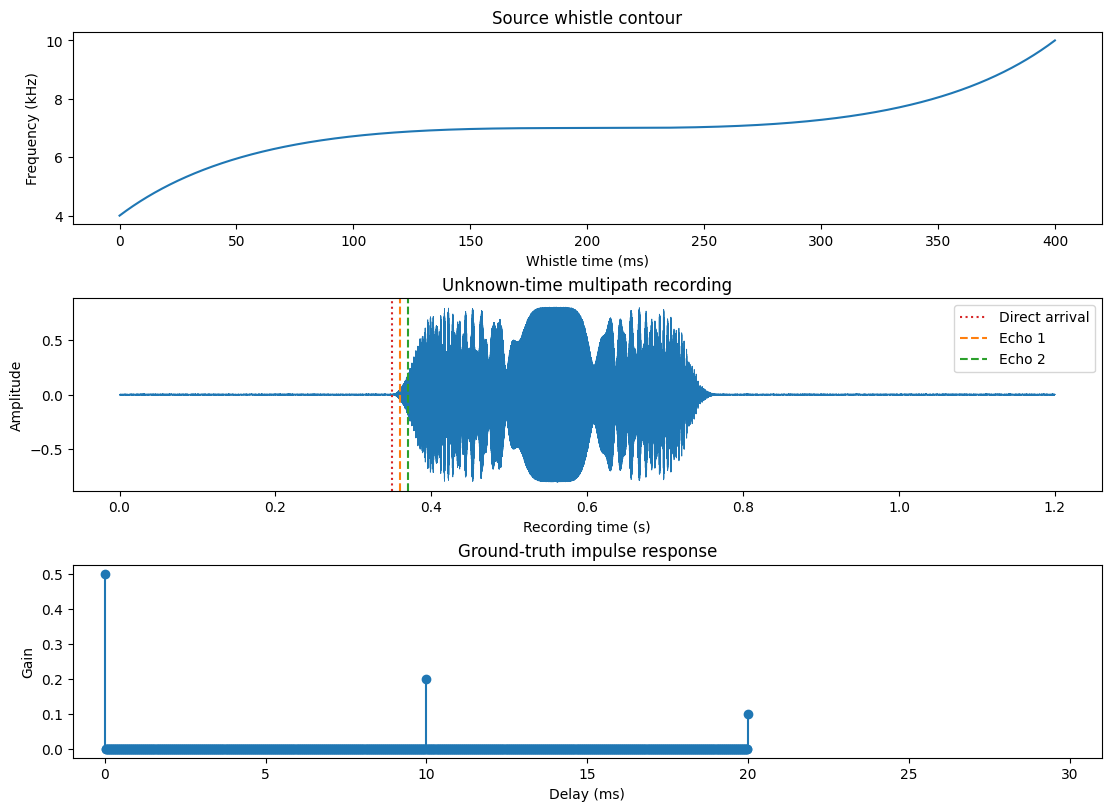

In [10]:
recording_time = np.arange(recording.size) / SAMPLE_RATE
figure, axes = plt.subplots(3, 1, figsize=(11, 8), constrained_layout=True)
axes[0].plot(source_time * 1e3, source_frequency / 1e3)
axes[0].set(title="Source whistle contour", xlabel="Whistle time (ms)", ylabel="Frequency (kHz)")
axes[1].plot(recording_time, recording, linewidth=0.6)
axes[1].axvline(WHISTLE_INSERTION_SECONDS, color="C3", linestyle=":", label="Direct arrival")
for index, delay in enumerate(TRUE_DELAY_SECONDS, start=1):
    axes[1].axvline(WHISTLE_INSERTION_SECONDS + delay, color=f"C{index}", linestyle="--", label=f"Echo {index}")
axes[1].set(title="Unknown-time multipath recording", xlabel="Recording time (s)", ylabel="Amplitude")
axes[1].legend()
axes[2].stem(np.arange(impulse_response.size) / SAMPLE_RATE * 1e3, impulse_response, basefmt=" " )
axes[2].set(xlim=(-1, CONFIG.max_delay_seconds * 1e3 + 1), title="Ground-truth impulse response", xlabel="Delay (ms)", ylabel="Gain")
plt.show()

## 3. Run the same unknown-time analysis pipeline

In [11]:
detections = detect_whistles(OUTPUT_WAV, CONFIG)
analysis = analyze_detections(OUTPUT_WAV, CONFIG, detections)
display([{"whistle": index, "start_s": item.start_seconds, "end_s": item.end_seconds, "detection_confidence": item.detection_confidence, "contour_confidence": item.contour_confidence} for index, item in enumerate(detections, start=1)])
calculated_delay_samples = analysis.whistles[0].delay_samples if len(analysis.whistles) == 1 else np.array([], dtype=int)
calculated_delay_seconds = calculated_delay_samples / SAMPLE_RATE
delay_errors_samples = np.abs(calculated_delay_samples - TRUE_DELAY_SAMPLES) if calculated_delay_samples.size == TRUE_DELAY_SAMPLES.size else np.array([], dtype=int)
validation_passed = len(analysis.whistles) == 1 and calculated_delay_samples.size == TRUE_DELAY_SAMPLES.size and np.all(delay_errors_samples <= 2)
comparison = []
for index in range(max(TRUE_DELAY_SAMPLES.size, calculated_delay_samples.size)):
    true_sample = int(TRUE_DELAY_SAMPLES[index]) if index < TRUE_DELAY_SAMPLES.size else None
    calculated_sample = int(calculated_delay_samples[index]) if index < calculated_delay_samples.size else None
    error_sample = abs(calculated_sample - true_sample) if true_sample is not None and calculated_sample is not None else None
    comparison.append({"echo": index + 1, "true_samples": true_sample, "true_ms": true_sample / SAMPLE_RATE * 1e3 if true_sample is not None else None, "calculated_samples": calculated_sample, "calculated_ms": calculated_sample / SAMPLE_RATE * 1e3 if calculated_sample is not None else None, "error_samples": error_sample})
display(comparison)
display({"result": "PASS" if validation_passed else "FAIL", "detected_whistles": len(analysis.whistles), "generated_wav": str(OUTPUT_WAV), "ground_truth": str(GROUND_TRUTH_FILE)})
print(f"Synthetic fixture validation: {'PASS' if validation_passed else 'FAIL'}")

[{'whistle': 1,
  'start_s': 0.35216666666666663,
  'end_s': 0.759875,
  'detection_confidence': 0.8522800585036726,
  'contour_confidence': 6.317081858176045}]

[{'echo': 1,
  'true_samples': 480,
  'true_ms': 10.0,
  'calculated_samples': 481,
  'calculated_ms': 10.020833333333332,
  'error_samples': 1},
 {'echo': 2,
  'true_samples': 960,
  'true_ms': 20.0,
  'calculated_samples': 960,
  'calculated_ms': 20.0,
  'error_samples': 0}]

{'result': 'PASS',
 'detected_whistles': 1,
 'generated_wav': 'synthetic_dolphin_chirp.wav',
 'ground_truth': 'synthetic_dolphin_chirp_ground_truth.npz'}

Synthetic fixture validation: PASS


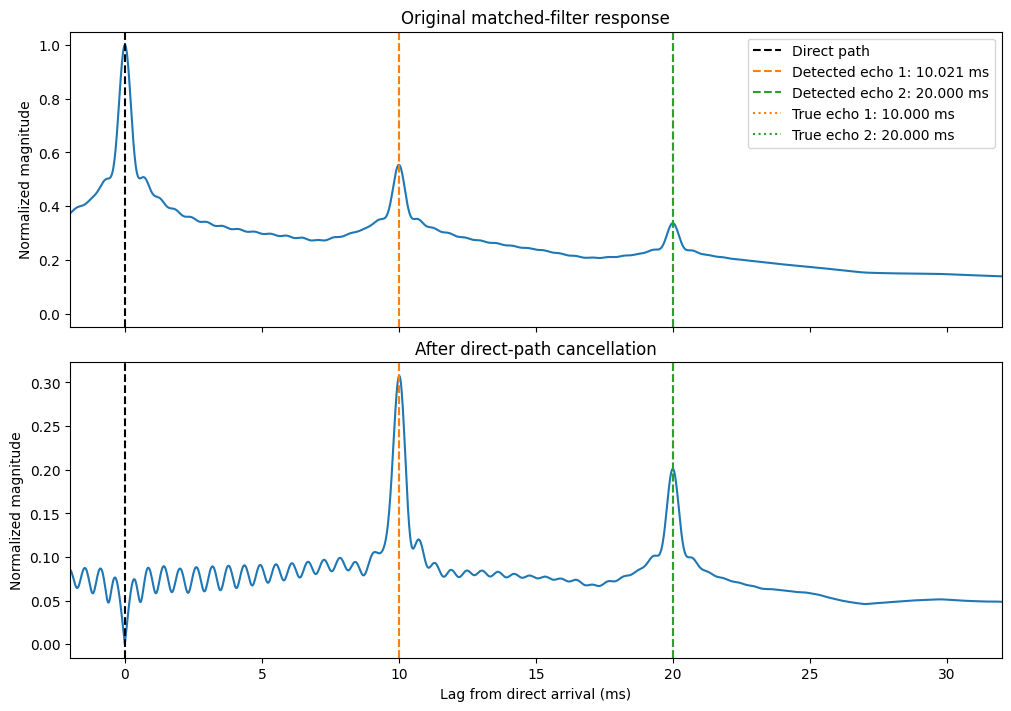

In [12]:
if analysis.whistles:
    result = analysis.whistles[0]
    relative_lag_ms = (result.lags - result.lags[result.direct_index]) / SAMPLE_RATE * 1e3
    scale = max(np.abs(result.response).max(), np.finfo(float).eps)
    figure, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, constrained_layout=True)
    for axis, response, title in ((axes[0], result.response, "Original matched-filter response"), (axes[1], result.residual_response, "After direct-path cancellation")):
        axis.plot(relative_lag_ms, np.abs(response) / scale)
        axis.axvline(0, color="black", linestyle="--", label="Direct path")
        for index, (echo_index, delay) in enumerate(zip(result.echo_indices, result.delay_seconds), start=1):
            axis.axvline(relative_lag_ms[echo_index], color=f"C{index}", linestyle="--", label=f"Detected echo {index}: {delay * 1e3:.3f} ms")
        for index, delay in enumerate(TRUE_DELAY_SECONDS, start=1):
            axis.axvline(delay * 1e3, color=f"C{index}", linestyle=":", label=f"True echo {index}: {delay * 1e3:.3f} ms")
        axis.set(ylabel="Normalized magnitude", title=title)
    axes[0].legend()
    axes[1].set(xlim=(-2, CONFIG.max_delay_seconds * 1e3 + 2), xlabel="Lag from direct arrival (ms)")
    plt.show()

## 4. Test the finding notebook

After this notebook reports `PASS`, open `Finding_Slant_delay.ipynb`. Its default `INPUT_WAV` points to the newly generated `synthetic_dolphin_chirp.wav`; that notebook must independently detect the whistle and calculate the same 10 ms and 20 ms delays.